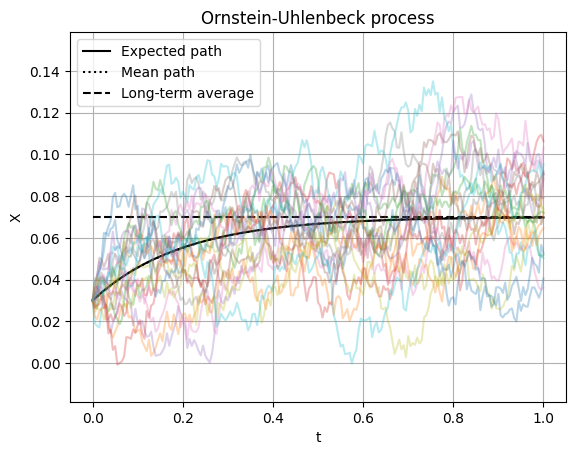

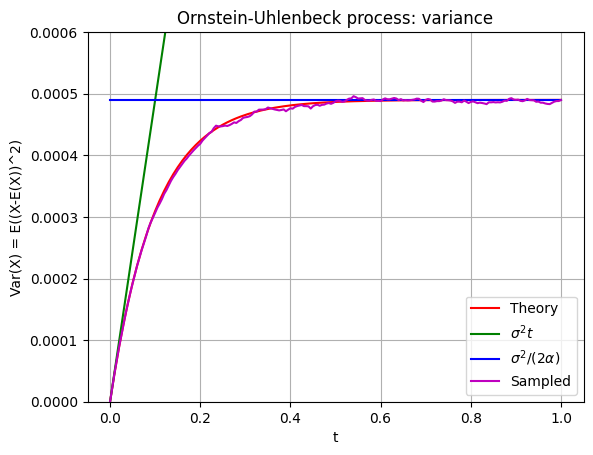

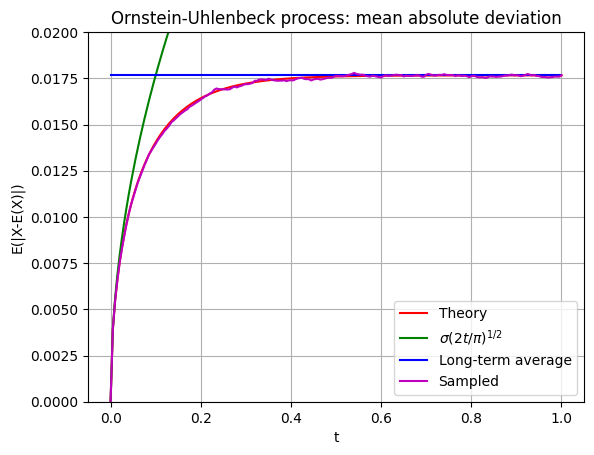

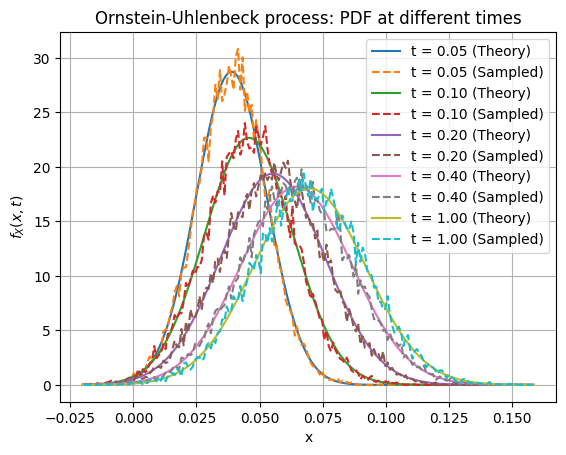

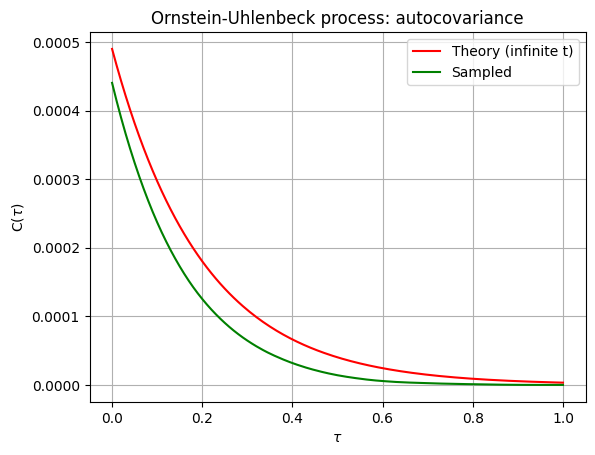

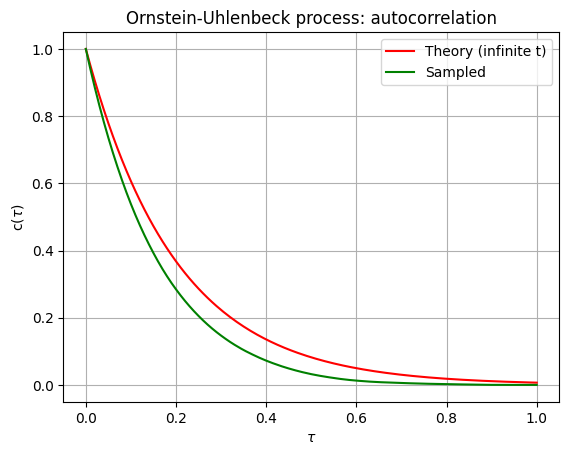

In [186]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# Define the parameters and the time grid
npaths = 20000  # number of paths
T = 1  # time horizon
nsteps = 200  # number of time steps
dt = T / nsteps  # time step
t = np.linspace(0, T, nsteps + 1)  # observation times
alpha, mu, sigma = 5, 0.07, 0.07  # model parameters
X0 = 0.03  # initial value

# Monte Carlo simulation
# Allocate and initialize all paths
X = np.zeros((nsteps + 1, npaths))
X[0, :] = X0

# Sample standard Gaussian random numbers
N = np.random.randn(nsteps, npaths)

# Compute the standard deviation for a time step
sdev = sigma * np.sqrt((1 - np.exp(-2 * alpha * dt)) / (2 * alpha))

# Compute and accumulate the increments
for i in range(nsteps):
    X[i + 1, :] = mu + (X[i, :] - mu) * np.exp(-alpha * dt) + sdev * N[i, :]

# Expected, mean, and sample paths
plt.figure(1)
EX = mu + (X0 - mu) * np.exp(-alpha * t)  # expected path
plt.plot(t, EX, 'k', label='Expected path')
plt.plot(t, np.mean(X, axis=1), 'k:', label='Mean path')
plt.plot(t, mu * np.ones_like(t), 'k--', label='Long-term average')
plt.plot(t, X[:, ::1000], alpha=0.3)
plt.xlabel('t')
plt.ylabel('X')
sdev_infty = sigma / np.sqrt(2 * alpha)
plt.ylim([mu - 4 * sdev_infty, mu + 4 * sdev_infty])
plt.legend()
plt.title('Ornstein-Uhlenbeck process')
plt.grid()
plt.savefig('oupaths.png')
plt.show()

# Variance
plt.figure(2)
plt.plot(t, sigma**2 / (2 * alpha) * (1 - np.exp(-2 * alpha * t)), 'r', label='Theory')
plt.plot(t, sigma**2 * t, 'g', label=r'$\sigma^2t$')
plt.plot(t, sigma**2 / (2 * alpha) * np.ones_like(t), 'b', label=r'$\sigma^2/(2\alpha)$')
plt.plot(t, np.var(X, axis=1), 'm', label='Sampled')
plt.xlabel('t')
plt.ylabel(r'Var(X) = E((X-E(X))^2)')
plt.ylim([0, 0.0006])
plt.legend()
plt.title('Ornstein-Uhlenbeck process: variance')
plt.grid()
plt.savefig('ouvariance.png')
plt.show()

# Mean absolute deviation
plt.figure(3)
plt.plot(t, sigma * np.sqrt((1 - np.exp(-2 * alpha * t)) / (np.pi * alpha)), 'r', label='Theory')
plt.plot(t, sigma * np.sqrt(2 * t / np.pi), 'g', label=r'$\sigma(2t/\pi)^{1/2}$')
plt.plot(t, sigma / np.sqrt(np.pi * alpha) * np.ones_like(t), 'b', label='Long-term average')
plt.plot(t, np.mean(np.abs(X - EX[:, None]), axis=1), 'm', label='Sampled')
plt.xlabel('t')
plt.ylabel(r'E(|X-E(X)|)')
plt.ylim([0, 0.02])
plt.legend()
plt.title('Ornstein-Uhlenbeck process: mean absolute deviation')
plt.grid()
plt.savefig('mad.png')
plt.show()

# Probability density function at different times
x = np.linspace(-0.02, mu + 4 * sdev_infty, 200)
t2 = [0.05, 0.1, 0.2, 0.4, 1]
EX2 = mu + (X0 - mu) * np.exp(-alpha * np.array(t2))
sdev_t2 = sigma * np.sqrt((1 - np.exp(-2 * alpha * np.array(t2))) / (2 * alpha))

fa = np.zeros((len(x), len(t2)))  # analytical PDF
fs = np.zeros((len(x) - 1, len(t2)))  # sampled PDF (adjusted for histogram bins)

for i, t_val in enumerate(t2):
    # Compute analytical PDF
    fa[:, i] = norm.pdf(x, loc=EX2[i], scale=sdev_t2[i])
    
    # Compute sampled PDF using histogram
    hist, bin_edges = np.histogram(X[int(t_val * nsteps), :], bins=x, density=True)
    fs[:, i] = hist  # Align with bin centers

# Plotting the analytical and sampled PDFs
plt.figure(4)
x_midpoints = (x[:-1] + x[1:]) / 2  # Midpoints of histogram bins
for i, t_val in enumerate(t2):
    plt.plot(x, fa[:, i], label=f't = {t_val:.2f} (Theory)')
    plt.plot(x_midpoints, fs[:, i], '--', label=f't = {t_val:.2f} (Sampled)')
plt.xlabel('x')
plt.ylabel(r'$f_X(x,t)$')
plt.legend()
plt.title('Ornstein-Uhlenbeck process: PDF at different times')
plt.grid()
plt.savefig('oudensities.png')
plt.show()

# Autocovariance
C = np.zeros((2 * nsteps + 1, npaths))
for j in range(npaths):
    C[:, j] = np.correlate(X[:, j] - EX, X[:, j] - EX, mode='full') / nsteps
C = np.mean(C, axis=1)
t_shifted = np.linspace(-T, T, 2 * nsteps + 1)

plt.figure(5)
plt.plot(t, sigma**2 / (2 * alpha) * np.exp(-alpha * t), 'r', label='Theory (infinite t)')
plt.plot(t, C[nsteps:], 'g', label='Sampled')
plt.xlabel(r'$\tau$')
plt.ylabel(r'C($\tau$)')
plt.legend()
plt.title('Ornstein-Uhlenbeck process: autocovariance')
plt.grid()
plt.savefig('ouautocov.png')
plt.show()

# Autocorrelation
plt.figure(6)
plt.plot(t, np.exp(-alpha * t), 'r', label='Theory (infinite t)')
plt.plot(t, C[nsteps:] / C[nsteps], 'g', label='Sampled')
plt.xlabel(r'$\tau$')
plt.ylabel(r'c($\tau$)')
plt.legend()
plt.title('Ornstein-Uhlenbeck process: autocorrelation')
plt.grid()
plt.savefig('ouautocorr.png')
plt.show()